# Activity: Let's Build a Regression Model of Housing Prices
In this activity, we'll develop a regression model to predict housing prices using multiple features. We'll explore different estimation methods, including traditional normal equations and Singular Value Decomposition (SVD), to understand their relative advantages in terms of numerical stability and handling multicollinearity.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We will develop a model to estimate housing prices based on factors like house area, bedrooms, furnished status, nearness to the main road, etc. The dataset is small; however, its complexity arises because it has strong multicollinearity. 

> __Acknowledgement__
> 
> The housing dataset is adapted from [Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?select=Housing.csv) and was originally used in:
>
> * Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.
> * Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

We've encoded [the `MyKaggleHousingPricesDataset()` helper function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.MyKaggleHousingPricesDataset) which returns the housing dataset [as a `DataFrame` instance](https://dataframes.juliadata.org/stable/).

Let's save the raw (unwrangled) data in the `original_dataset::DataFrame` variable:

In [2]:
original_dataset = MyKaggleHousingPricesDataset() # load the *original* dataset

Row,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
,Int64,Int64,Int64,Int64,Int64,String3,String3,String3,String3,String3,Int64,String3,String15
1,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
2,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
4,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
5,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
6,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
7,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
8,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
9,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished


Notice that we have several columns (features) that are categorical, i.e., `{furnished | unfurnished | semifurnished}` or `{yes | no}`. We must replace these values with numbers, e.g., `{0 | 1 | 2}`, etc.
 > __Transformation:__ We'll transform the categorical features (including changing types from a `String` to an `Int`) using [the `transform!(...)` method exported by the DataFrames.jl package](https://dataframes.juliadata.org/stable/lib/functions/#DataFrames.transform!). This is an advanced operation, so if this is unclear, please review the [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/lib/functions/#DataFrames.transform!) for more information.

 We'll save the transformed dataset in the `treated_dataset::DataFrame` variable:

In [3]:
treated_dataset = let

    treated_dataset = copy(original_dataset);    
    transform!(treated_dataset, :mainroad => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_mainroad);
    transform!(treated_dataset, :guestroom => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_guestroom);
    transform!(treated_dataset, :basement => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_basement);
    transform!(treated_dataset, :hotwaterheating => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_hotwaterheating);
    transform!(treated_dataset, :airconditioning => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_airconditioning);
    transform!(treated_dataset, :prefarea => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_prefarea);
    transform!(treated_dataset, :furnishingstatus => ByRow( x-> (x=="unfurnished" ? -1 : (x=="semi-furnished" ? 0 : 1))) => :t_furnishingstatus);
    transform!(treated_dataset, :price => ByRow(x -> x/1000000.0) => :t_price);
    transform!(treated_dataset, :area => ByRow(x -> x/1000.0) => :t_area);

    # remove the original columns
    select!(treated_dataset, Not([:mainroad,:guestroom,:basement,:hotwaterheating,:airconditioning,:prefarea,:furnishingstatus,:price, :area]))
end

Row,bedrooms,bathrooms,stories,parking,t_mainroad,t_guestroom,t_basement,t_hotwaterheating,t_airconditioning,t_prefarea,t_furnishingstatus,t_price,t_area
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64
1,4,2,3,2,1,-1,-1,-1,1,1,1,13.3,7.42
2,4,4,4,3,1,-1,-1,-1,1,-1,1,12.25,8.96
3,3,2,2,2,1,-1,1,-1,-1,1,0,12.25,9.96
4,4,2,2,3,1,-1,1,-1,1,1,1,12.215,7.5
5,4,1,2,2,1,1,1,-1,1,-1,1,11.41,7.42
6,3,3,1,2,1,-1,1,-1,1,1,0,10.85,7.5
7,4,3,4,2,1,-1,-1,-1,1,1,0,10.15,8.58
8,5,3,2,0,1,-1,-1,-1,-1,-1,-1,10.15,16.2
9,4,1,2,2,1,1,1,-1,1,1,1,9.87,8.1


Now let's split the dataset into the system input matrix $\mathbf{X}$ (independent variables, characteristics of the house) and the output vector $\mathbf{y}$ (dependent variable, the house price).

The input matrix $\mathbf{X}$ will contain all the columns except for the `price` column (the output variable). The output vector $\mathbf{y}$ will contain only the `price` column.

In [ ]:
X = Matrix(treated_dataset[:, Not(:t_price)]); # data matrix: select all the columns *except* price
y = Vector(treated_dataset[:,:t_price]); # output vector: select the price column

Finally, let's partition the data into a `training` and `testing` set so that we can determine how well the model can predict unseen data, i.e., how well the model generalizes.

In [5]:
training, testing = let

    # initialize -
    s = 0.80; # fraction of data for training
    number_of_training_samples = Int(s * size(X,1)); # 80% of the data for training
    i = randperm(size(X,1)); # random permutation of the indices
    training_indices = i[1:number_of_training_samples]; # first 80% of the indices
    testing_indices = i[number_of_training_samples+1:end]; # last 20% of
    

    # setup training -
    one_vector = ones(number_of_training_samples);
    training = (X=[X[training_indices, :] one_vector], y=y[training_indices]);

    # setup testing -
    one_vector = ones(length(testing_indices));
    testing = (X=[X[testing_indices, :] one_vector], y=y[testing_indices]);

    training, testing;
end;

___

## Task 1: Estimate model parameters without regularization
We know that the data matrix $\mathbf{X}\in\mathbb{R}^{m\times n}$ is overdetermined, i.e., $m>n$ (more equations than unknowns). Thus, we are solving the minimization problem for unknown parameter estimates $\hat{\theta}$:
$$
\begin{equation*}
\hat{\mathbf{\theta}} = \arg\min_{\mathbf{\theta}} ||~\mathbf{y} - \mathbf{X}\;\mathbf{\theta}~||^{2}_{2}
\end{equation*}
$$
where $||\star||^{2}_{2}$ is the square of the p = 2 vector norm. Then, the value of the unknown parameter vector $\mathbf{\theta}$ that minimizes the sum of squares loss function for an overdetermined system is given by:
$$
\begin{align*}
\hat{\mathbf{\theta}} &= \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y} \\
\end{align*}
$$

If we wanted to understand the error in the parameter estimates $\hat{\mathbf{\theta}}$, we could substitute the model $\mathbf{y}$ generated by a linear model with some error term $\mathbf{\epsilon}$:
$$
\begin{align*}
\hat{\mathbf{\theta}} &= \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y} \\
\hat{\mathbf{\theta}}&= \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}(\hat{\mathbf{X}}\;\mathbf{\theta} + \mathbf{\epsilon}) \\
\hat{\mathbf{\theta}} &= \underbrace{\left[\left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right]}_{= \mathbf{I}}\;\mathbf{\theta} + \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{\epsilon}\\
\hat{\mathbf{\theta}} &= \mathbf{\theta} + \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{\epsilon}\quad\blacksquare\\
\end{align*}
$$

Let's compute an estimate of the model parameters $\hat{\mathbf{\theta}}$ using the training dataset.

In [6]:
θ̂₁  = let

    # initialize -
    X = training.X;
    y = training.y;
    θ = inv(transpose(X)*X)*transpose(X)*y; # normal equations 

    θ; # return
end;

Now that we have the model parameters, let's evaluate the model performance on the `testing` dataset.

We can compute the predicted output vector $\hat{\mathbf{y}}$ using the learned model parameters $\hat{\mathbf{\theta}}$ and the input matrix $\mathbf{X}$ from the `training` and `testing` datasets. 

We'll save the model output for the `training` dataset in the `predicted_training_y::Vector{Float64}` variable and the model output for the `testing` dataset in the `predicted_testing_y::Vector{Float64}` variable.

In [7]:
predicted_training_y = training.X * θ̂₁; # predicted output for the training data
predicted_testing_y = testing.X * θ̂₁; # predicted output for the testing data

### Analysis: Training and Testing Error
Let's compute the error for the training case. 

> __Error:__ Use [the `norm(...)` function exported by the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.norm) to compute the distance (error) between the observed output and the calculated output values. We store this in the `δ_train` variable. The larger the `δ_train,` the __worse__ the model is learning the data. Thus, a large value of `δ_train` is bad.

So, what is the value of `δ_train::Float64`?

In [8]:
δ_train = let
    
    # initialize -
    N = length(predicted_training_y);
    y = training.y;

    # compute a scaled training error -
    ϵ = (1/N)*(y .- predicted_training_y)
    δ_train = norm(ϵ);

    δ_train; # return
end

0.050414241856157026

We can do the same analysis for the `testing` dataset. We'll save the error metric in the `δ_test::Float64` variable.

In [9]:
δ_test = let
    
    # initialize -
    N = length(predicted_testing_y);
    y = testing.y;
    
    # compute a scaled testing error -
    ϵ = (1/N)*(y .- predicted_testing_y)
    δ_test = norm(ϵ);

    δ_test; # return
end

0.10460392349555375

The code block below shows how we plot the computed and observed home prices for a model without regularization for both the _training data_ and _test data_.

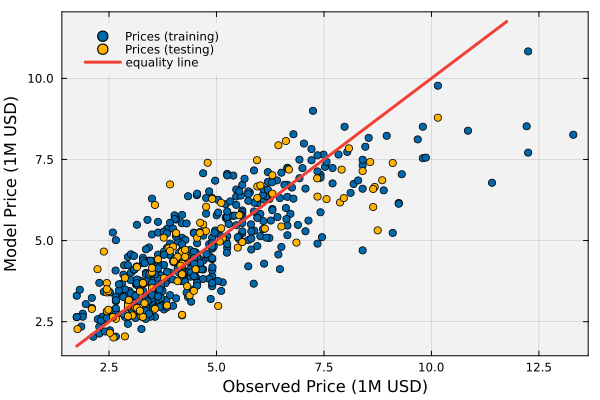

In [10]:
let

    # initialize -
    y_train = training.y;
    ŷ_train = predicted_training_y;
    y_test = testing.y;
    ŷ_test = predicted_testing_y;

    # plot -
    xy_line = min(minimum(ŷ_train), minimum(y_train)):10:max(maximum(y_train),maximum(y_train)) |> collect;
    scatter(y_train,ŷ_train,label="Prices (training)",c=colorant"#0068AC")
    scatter!(y_test,ŷ_test,label="Prices (testing)",c=colorant"#FFB300")
    plot!(xy_line,xy_line,lw=3, label="equality line", c=colorant"#EF4035");
   
    xlabel!("Observed Price (1M USD)", fontsize=18)
    ylabel!("Model Price (1M USD)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

## Task 2: Estimate Parameter Confidence Intervals
In this task, let's compute the confidence intervals for the estimated model parameters $\hat{\mathbf{\theta}}$. To do this, we need to compute the standard errors of the parameter estimates $\mathrm{SE}(\hat{\mathbf{\theta}})$, which requires us to estimate the variance of the error terms $\hat{\sigma}^{2}$. 

Let's start there.

> __Theory:__ Since the __true__ variance $\sigma^2$ is unknown, we can estimate the population variance $\hat{\sigma}^2$ from the residuals $\mathbf{r} = \mathbf{y} - \hat{\mathbf{X}}\hat{\mathbf{\theta}}$ as:
> $$
\begin{align*}
\hat{\sigma}^{2} &= \frac{\lVert~\mathbf{r}~\rVert^{2}_{2}}{n-p} = \frac{1}{n-p}\sum_{i=1}^{n}r_i^2
\end{align*}
> $$
> where $n$ is the number of observations, $p$ is the number of parameters, $\lVert\star\rVert_{2}^{2}$ denotes the p = 2 norm squared, and $r_i = y_i - \hat{\mathbf{x}}_i^{\top}\hat{\mathbf{\theta}}$ is the $i$-th residual, i.e., the difference between the observed and predicted value for observation $i$.

We implement this computation in the code block below and save the result in the `training_variance::Float64` variable.

In [11]:
training_variance = let

    # initialize -
    y = training.y; # training output
    X = training.X; # training data matrix
    p = length(θ̂₁); # number of parameters
    n = size(X,1); # number of training observations

    # compute the residual -
    r = y .- X*θ̂₁;
    
    # variance -
    my_variance = (1/(n-p))*norm(r)^2

    # let's compute the variance of the residuals (Julia)
    built_in_variance = var(r, corrected=true); # variance - Julia
    @show built_in_variance, my_variance; # show

    my_variance; # return
end;

(built_in_variance, my_variance) = (1.1106831994528121, 1.1421919426997007)



Next, let's compute the standard error. The standard error of the parameter estimates $\hat{\mathbf{\theta}}$ quantifies the uncertainty in the estimated parameters due to the variability in the data. Let's compute the standard error for each parameter $\hat{\theta}_j$ that we estimated in Task 1.

We save the standard errors in the `SE::Vector{Float64}` variable, where element $j$ corresponds to the standard error of a parameter estimate $\text{SE}(\hat{\theta}_j)$.

In [12]:
SE = let
    
    # initialize -
    X = training.X;
    p = length(θ̂₁); # number of parameters
    n = size(X,1); # number of training samples

    # compute the standard error -
    SE = sqrt.(diag(inv(transpose(X)*X))*training_variance);

    SE; # return
end;

Now that we have the standard error for each of the model parameters, we can compute the uncertainty in the parameter estimates $\hat{\mathbf{\theta}}$. Let's compute confidence intervals for each parameter estimate.
> __Confidence Intervals:__ A $(1-\alpha)\times{100}\%$ confidence interval for each parameter $\hat{\theta}_j$ is given by:
> $$
\begin{align*}
\hat{\theta}_j \pm t_{1-\alpha/2,\nu}\; \hat{\sigma}\; \sqrt{\bigl[(\hat{\mathbf X}^\top\hat{\mathbf X})^{-1}\bigr]_{jj}}
\end{align*}
> $$
> where $t_{1-\alpha/2,\nu}$ is the $(1-\alpha/2)$-quantile of a Student $t$ distribution with $\nu$ degrees of freedom. For a 95% confidence interval, $\alpha = 0.05$ and $t_{1-\alpha/2,\nu} \approx 1.96$. For a 99.9% confidence interval, $\alpha = 0.001$ and $t_{1-\alpha/2,\nu} \approx 3.291$.

Let's build a table that shows the parameter ranges for a 95.0% confidence interval using [the `PrettyTables.jl` package](https://github.com/ronisbr/PrettyTables.jl). (You can adjust this to show another confidence interval if you like).

In [13]:
let

    # initialize -
    t = 1.96; # for a 95% confidence interval
    df = DataFrame(); # hold the data (rows) for the table

    # build features of the table -
    feature_labels = Array{String,1}();
    names_of_treated_dataset = names(treated_dataset);
    for i ∈ eachindex(names_of_treated_dataset)

        colname = names_of_treated_dataset[i];
        if colname == "t_price"
            continue; # skip the price column
        end
        push!(feature_labels, colname);
    end
    push!(feature_labels, "intercept"); # add the intercept label

    for i ∈ eachindex(θ̂₁)

        center = θ̂₁[i];
        lower_bound = θ̂₁[i] - t*SE[i];
        upper_bound = θ̂₁[i] + t*SE[i];

        row_df = (
            i = i,
            feature = feature_labels[i],
            p = round(center, digits=4),
            l = round(lower_bound, digits=4),
            u = round(upper_bound, digits=4),
            cz = (lower_bound <= 0.0 <= upper_bound ? "yes" : "no")
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # show the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__simple)) # new table API. Hmmm
end


======== ==================== ========= ========= ========= =========
      i              feature         p         l         u       cz 
  Int64               String   Float64   Float64   Float64   String 
======== ==================== ========= ========= ========= =========
      1             bedrooms    0.1517   -0.0116    0.3151      yes
      2            bathrooms    1.0085    0.7805    1.2365       no
      3              stories     0.442    0.2974    0.5867       no
      4              parking    0.3148    0.1864    0.4432       no
      5           t_mainroad    0.2256    0.0629    0.3882       no
      6          t_guestroom     0.102   -0.0404    0.2445      yes
      7           t_basement    0.1836    0.0628    0.3043       no
      8    t_hotwaterheating    0.3301    0.1047    0.5556       no
      9    t_airconditioning    0.3697      0.25    0.4893       no
     10           t_prefarea    0.3004    0.1754    0.4253       no
     11   t_furnishingstatus    0.2373    

__Analysis:__ Based on the confidence intervals, which parameters are __statistically stable?__ (i.e., which parameters have confidence intervals that do not include zero?) How might this information be useful in refining the model?

> __What do we see?__ What you see may depend on the random partitioning of the data into `training` and `testing` sets. However, some parameters have confidence intervals that include zero, e.g., parameters `1` and `6`, indicating that these parameters may not be statistically significant. This is interesting because parameter `1` corresponds to the number of bedrooms (surprisingly) and parameter `6` corresponds to the presence of a guest room (not so surprisingly).

> __So what?__ This information can be useful in refining the model by identifying features that do not contribute significantly to predicting housing prices. By removing these less significant features, we can simplify the model, potentially improve its interpretability, and reduce overfitting. Additionally, focusing on statistically significant parameters can help in understanding the key factors that influence housing prices, leading to more informed decision-making in real estate and urban planning contexts.

## Task 3: SVD-Based Parameter Estimation and Numerical Stability

In Tasks 1 and 2, we used the normal equations approach: $\hat{\mathbf{\theta}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}$. However, this approach can be numerically unstable when the data matrix $\hat{\mathbf{X}}$ has a high condition number (multicollinearity). 

Let's use **Singular Value Decomposition (SVD)** to estimate the parameters more robustly.

> **Theory:** If $\hat{\mathbf{X}} = \mathbf{U}\mathbf{S}\mathbf{V}^{\top}$ is the SVD decomposition of $\hat{\mathbf{X}}$, then the least squares solution becomes:
> $$\hat{\mathbf{\theta}} = \mathbf{V}\mathbf{S}^{+}\mathbf{U}^{\top}\mathbf{y}$$
> where $\mathbf{S}^{+}$ is the Moore-Penrose pseudoinverse of the diagonal matrix $\mathbf{S}$. This approach is more numerically stable and handles rank-deficient matrices gracefully.

How about our system?

### Condition Number Analysis
First, let's analyze the numerical conditioning of our data matrix $\hat{\mathbf{X}}$ using the condition number $\kappa_2(\hat{\mathbf{X}})$, which is defined as:
$$
\kappa_2(\hat{\mathbf{X}}) = ||\hat{\mathbf{X}}||_2 \; ||\hat{\mathbf{X}}^{+}||_2
$$
where $||\star||_2$ is the p = 2 matrix norm (largest singular value) and $\hat{\mathbf{X}}^{+}$ is the Moore-Penrose pseudoinverse of $\hat{\mathbf{X}}$. However, we don't need to implement this directly. Instead, we can use [the `cond(...)` function exported by the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.cond) to compute the condition number directly.

In [14]:
condition_analysis = let
    
    # initialize -
    X = training.X;
    
    # condition number analysis
    condition_normal = cond(transpose(X)*X);  # condition number of X'X (normal equations)
    condition_svd = cond(X);  # condition number of X (SVD approach)
    
    # SVD decomposition
    U, S, V = svd(X);
    
    println("Condition number (Normal equations): ", round(condition_normal, digits=2))
    println("Condition number (SVD approach): ", round(condition_svd, digits=2))
    println("Smallest singular value: ", round(minimum(S), digits=6))
    println("Largest singular value: ", round(maximum(S), digits=2))
    println("Ratio (largest/smallest): ", round(maximum(S)/minimum(S), digits=2))
    
    (condition_normal=condition_normal, condition_svd=condition_svd, U=U, S=S, V=V)
end;

Condition number (Normal equations): 1908.59
Condition number (SVD approach): 43.69
Smallest singular value: 3.255819
Largest singular value: 142.24
Ratio (largest/smallest): 43.69


#### What do these condition numbers tell us?

The results above reveal important insights about the numerical stability of our housing price regression:

> **Condition Number Analysis:**
> - **Normal equations**: 1908.59 (quite high!)
> - **SVD approach**: 43.69 (much more reasonable)
> 
> **What this means:** The condition number of $\mathbf{X}^{\top}\mathbf{X}$ is dramatically higher than the condition number of $\mathbf{X}$ itself. This happens because forming $\mathbf{X}^{\top}\mathbf{X}$ squares the condition number, amplifying numerical errors.

> **Singular Value Spread:**
> - **Largest singular value**: 142.24
> - **Smallest singular value**: 3.26
> - **Ratio**: 43.69 (this equals the condition number of $\mathbf{X}$)
> 
> **Interpretation:** While we do have some spread in our singular values (indicating mild multicollinearity), the ratio of 43.69 is quite reasonable. Values above 1000 would indicate severe numerical instability.

**Bottom line:** Our dataset shows moderate multicollinearity (as we know from the dataset authors) but is numerically well-behaved. The SVD approach provides better numerical stability than normal equations, though both should work reasonably well for this problem.

### SVD Parameter Estimation
Now let's compute the parameter estimates using SVD and compare them with the normal equations approach. We store the parameters estimated using SVD in the `θ̂₂:;Array{Float64,1}` variable:

In [15]:
θ̂₂ = let
    
    # initialize -
    X = training.X;
    y = training.y;
    U, S, V = condition_analysis.U, condition_analysis.S, condition_analysis.V;
    
    # SVD-based parameter estimation
    # θ = V * S⁺ * U' * y, where S⁺ is pseudoinverse of S
    S_pseudoinv = diagm(1 ./ S);  # pseudoinverse for full rank case
    θ_svd = V * S_pseudoinv * transpose(U) * y;
    
    # Alternative: use built-in pseudoinverse (handles rank deficiency automatically)
    θ_svd_builtin = pinv(X) * y;
    
    println("Parameter difference (SVD vs Normal): ", norm(θ_svd - θ̂₁))
    println("Parameter difference (SVD builtin vs Normal): ", norm(θ_svd_builtin - θ̂₁))
    
    θ_svd; # return SVD-based estimate
end;

Parameter difference (SVD vs Normal): 2.345630657971507e-14
Parameter difference (SVD builtin vs Normal): 2.4006298607403205e-14

Parameter difference (SVD builtin vs Normal): 2.4006298607403205e-14


#### What do these tiny parameter differences mean?

The results above show parameter differences on the order of $\sim10^{-14}$. Yes, these are __super small numbers__, but that's actually the **good news**!

> **Why are these numbers so small?**
> 
> These differences are at the level of **machine precision** for 64-bit floating point numbers. In Julia, `eps(Float64) ≈ 2.22e-16`, so our differences are only about 100 times larger than the smallest representable difference between floating point numbers.

> **What does this tell us?**
> 
> 1. **Mathematical Equivalence**: SVD and normal equations are giving us essentially identical parameter estimates
> 2. **Numerical Validation**: Both our manual SVD implementation and Julia's built-in [`pinv(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.pinv) agree to machine precision
> 3. **Well-Conditioned Problem**: Since we get nearly identical results, our housing price problem isn't suffering from severe numerical instability
> 
> **The key insight:** These tiny differences confirm that for our dataset, both methods work well numerically. The value of SVD isn't that it gives dramatically different parameters, but rather that it provides:
> - Better numerical stability (especially important for ill-conditioned problems)
> - Diagnostic information (condition numbers, singular values)
> - Natural handling of rank-deficient cases
> - Built-in regularization capabilities (via truncation)

**Bottom line:** Small parameter differences are exactly what we want to see - it means both methods are working correctly and our problem is numerically well-behaved!

### Rank Truncation Analysis
One advantage of SVD is that we can easily handle multicollinearity by truncating small singular values. Let's explore how this affects our parameter estimates. We are going to look at the training and testing error as a function of the __rank__.

> __Rank definition:__ In our SVD analysis, __rank__ refers to how many singular values (and their corresponding singular vectors) we keep in our approximation. When we say rank `13`, we're using __all__ `13` singular values, i.e., the full model. When we say rank `1`, we're using __only the largest__ singular value (a severely truncated model).

What does this analysis give for this example?

In [20]:
truncation_analysis = let
    
    # initialize -
    X = training.X;
    y = training.y;
    U, S, V = condition_analysis.U, condition_analysis.S, condition_analysis.V;
    results_df = DataFrame();
    
    # try different truncation levels
    truncation_results = [];
    rank_range_array = range(length(S),   stop = 1, step = -1) |> collect;
    for k ∈ rank_range_array # different ranks
        
        if k > length(S)
            continue
        end
        
        # truncated SVD reconstruction
        S_k = copy(S);
        S_k[k+1:end] .= 0.0;  # zero out small singular values
        
        # parameter estimation with truncated SVD
        S_k_inv = diagm([s > 1e-10 ? 1/s : 0.0 for s in S_k]);
        θ_k = V * S_k_inv * transpose(U) * y;
        
        # prediction error
        y_pred = X * θ_k;
        train_error = norm(training.y - y_pred) / length(training.y);
        test_error = norm(testing.y - testing.X * θ_k) / length(testing.y);
        
        push!(truncation_results, (rank=k, θ=θ_k, train_error=train_error, test_error=test_error));
    end

    # store results in a DataFrame
    for result ∈ truncation_results
        
        row_df = (
            rank = result.rank,
            train_error = round(result.train_error, digits=4),
            test_error = round(result.test_error, digits=4)
        )
        push!(results_df, row_df);
    end

    # show the table -
    pretty_table(results_df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__simple)) # new table API. Hmmm
    
   
    truncation_results; # return 
end;

======== ============= =============
   rank   train_error   test_error 
  Int64       Float64      Float64 
======== ============= =============
     13        0.0504       0.1046
     12        0.0512       0.1117
     11        0.0541       0.1168
     10        0.0545       0.1172
      9        0.0548       0.1168
      8        0.0548       0.1169
      7        0.0549       0.1172
      6        0.0549       0.1172
      5        0.0549       0.1172
      4        0.0559       0.1159
      3        0.0562        0.117
      2         0.069       0.1536
      1        0.0693       0.1549
======== ============= =============


### Analysis and Comparison

__Analysis:__ Based on the condition number analysis and rank truncation results, what can we conclude about the numerical stability of our housing price regression model? How does SVD help us deal with multicollinearity in this dataset?

> __What do we see?__ The condition number analysis reveals important information about the numerical stability of our system. If the condition number of $\mathbf{X}^{\top}\mathbf{X}$ (normal equations approach) is significantly larger than the condition number of $\mathbf{X}$ (SVD approach), this indicates that the normal equations amplify numerical errors. This is particularly problematic when we have multicollinearity in our housing features.

> __Rank truncation insights:__ The rank truncation analysis shows us something important about our housing dataset. By systematically removing the smallest singular values (which correspond to the least important directions in our feature space), we can see how much information each component contributes. Look at the table above: as we reduce the effective rank of our system, what happens to the training vs. testing error? In this case, both errors tend to increase as we remove information, suggesting that our features are not highly redundant.

> __So what?__ This tells us something important about our housing dataset: **all the information appears to be useful**. Unlike cases where we have severe multicollinearity or overfitting, our rank truncation results show that performance degrades as we remove information. This suggests we have a well-balanced problem where the features provide complementary information about housing prices.

__Key practical takeaways:__

* **When should you use SVD instead of normal equations?** If your condition number is high (> 1000), you're dealing with multicollinear features, or you suspect your model is overfitting, SVD provides a more robust alternative.

* **How do you interpret rank truncation results?** If test error increases significantly as rank decreases (like in our case), it means your features are providing valuable, non-redundant information. If test error decreases, you may be overfitting or have redundant features.

* **What's the computational cost?** SVD is more expensive computationally than normal equations, but it's often worth it for the numerical stability and diagnostic capabilities it provides.

What is the rank test telling us?

#### Why does test error increase as rank decreases?
> This is exactly what we should expect! Here's why:
> - **Rank 13** (full model): Uses all available information, should have the best fit to training data and often the best test performance
> - **Rank 1** (most truncated): Uses only the dominant pattern in the data, discarding a lot of information
> 
> Our results show `test_error` going from 0.1046 (rank `13`) to 0.1549 (rank `1`). This means the housing price data __benefits from the full complexity__, i.e., we're not in an overfitting regime where simpler models perform better.

This result tells us the data is not heavily overfitted; if it were, we'd see test error decrease as we reduced rank. But what does it mean if we observe the opposite trend? In that case, we would expect that __multicollinearity__ exists (multiple features measure nearly the same thing), and we are overfitting the noise in the training data.

___